In [6]:
# 1. Gerekli kütüphaneleri içe aktarma
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from PIL import Image
from tqdm import tqdm
import os



In [7]:
# 2. VGG16 modelini yükleme (sadece özellik çıkarımı için üst katmanlar hariç)
temel_model = VGG16(weights='imagenet', include_top=False, pooling='avg')
model = Model(inputs=temel_model.input, outputs=temel_model.output)



In [8]:
# 3. Görsel ön işleme fonksiyonu
def resmi_on_isle(resim_yolu):
    img = image.load_img(resim_yolu, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x



In [25]:
# 4. Google Colab üzerinden örnek görselleri yükleme
from google.colab import files
print("Veri seti için görselleri yükleyin:")
yuklenenler = files.upload() # 5-10 adet JPEG veya PNG sanat eseri resmi yükleyin
resim_yollari = list(yuklenenler.keys())



Veri seti için görselleri yükleyin:


Saving jonathan-borba-O5CDmok2rkA-unsplash.jpg to jonathan-borba-O5CDmok2rkA-unsplash.jpg
Saving ruben-mavarez-DaXeaSWr_Lo-unsplash.jpg to ruben-mavarez-DaXeaSWr_Lo-unsplash.jpg
Saving allec-gomes-xnRg3xDcNnE-unsplash.jpg to allec-gomes-xnRg3xDcNnE-unsplash (1).jpg
Saving mike-dorner-sf_1ZDA1YFw-unsplash.jpg to mike-dorner-sf_1ZDA1YFw-unsplash (1).jpg
Saving alchemyrefiner_alchemymagic_3_f839a945-ba27-474e-9671-3643d25f2c89_0.jpg to alchemyrefiner_alchemymagic_3_f839a945-ba27-474e-9671-3643d25f2c89_0 (1).jpg
Saving alchemyrefiner_alchemymagic_2_3d6f6eea-67e8-47bc-a30c-f0bfcee55068_0.jpg to alchemyrefiner_alchemymagic_2_3d6f6eea-67e8-47bc-a30c-f0bfcee55068_0 (1).jpg
Saving Default_A_photorealistic_Fuji_XT5_photography_glitching_digita_0_9247fae6-73ad-497b-99cb-045f2222668f_0.jpg to Default_A_photorealistic_Fuji_XT5_photography_glitching_digita_0_9247fae6-73ad-497b-99cb-045f2222668f_0 (1).jpg


In [19]:
# 5. Yüklenen görsellerden yerleştirmeleri (embeddings) oluşturma
yerlestirmeler = []
for yol in tqdm(resim_yollari):
    img = resmi_on_isle(yol)
    ozellikler = model.predict(img)
    yerlestirmeler.append(ozellikler.flatten())

yerlestirmeler = np.array(yerlestirmeler)



  0%|          | 0/9 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step


 11%|█         | 1/9 [00:02<00:19,  2.42s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step


 22%|██▏       | 2/9 [00:03<00:10,  1.50s/it]

...

 78%|███████▊  | 7/9 [00:06<00:01,  1.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step


 89%|████████▉ | 8/9 [00:07<00:00,  1.32it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step


100%|██████████| 9/9 [00:08<00:00,  1.09it/s]


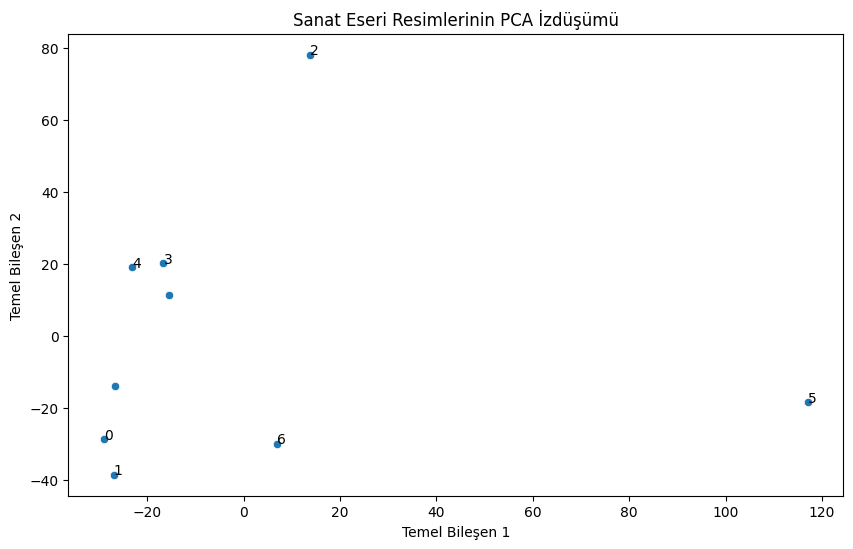

In [28]:
# 6. PCA (Temel Bileşen Analizi) ile boyut indirgeme ve görselleştirme
pca = PCA(n_components=2)
pca_sonucu = pca.fit_transform(yerlestirmeler)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_sonucu[:, 0], y=pca_sonucu[:, 1])

for i, yol in enumerate(resim_yollari):
    plt.annotate(f"{i}", (pca_sonucu[i, 0], pca_sonucu[i, 1]))

plt.title("Sanat Eseri Resimlerinin PCA İzdüşümü")
plt.xlabel("Temel Bileşen 1")
plt.ylabel("Temel Bileşen 2")
plt.show()



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


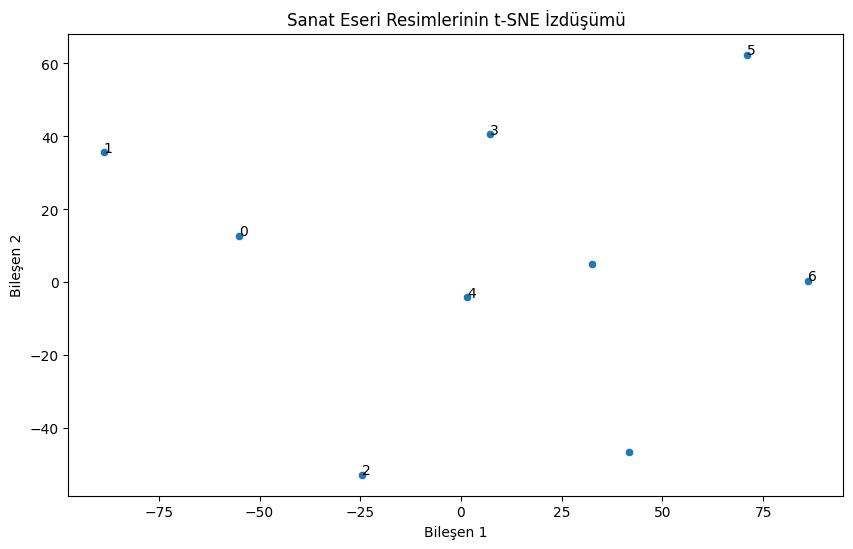

In [29]:
# 7. t-SNE ile boyut indirgeme ve kümeleri görselleştirme
tsne = TSNE(n_components=2, perplexity=3, n_iter=1000, random_state=42) # perplexity 5'ten küçük olmalı, örneğin 3 olarak ayarlandı
tsne_sonucu = tsne.fit_transform(yerlestirmeler)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_sonucu[:, 0], y=tsne_sonucu[:, 1])

for i, yol in enumerate(resim_yollari):
    plt.annotate(f"{i}", (tsne_sonucu[i, 0], tsne_sonucu[i, 1]))

plt.title("Sanat Eseri Resimlerinin t-SNE İzdüşümü")
plt.xlabel("Bileşen 1")
plt.ylabel("Bileşen 2")
plt.show()

In [30]:
# 8. Benzerlik araması için bir test (sorgu) resmi yükleme
print("Benzerlerini aramak istediğiniz sorgu resmini yükleyin:")
yuklenen_test = files.upload()
test_yolu = list(yuklenen_test.keys())[0]
test_resmi = resmi_on_isle(test_yolu)
test_yerlestirmesi = model.predict(test_resmi).flatten()


Benzerlerini aramak istediğiniz sorgu resmini yükleyin:


Saving lucid-origin_A_black_cat_with_a_powerful_commanding_presence_designed_in_a_dark_fantasy_cinem-0.jpg to lucid-origin_A_black_cat_with_a_powerful_commanding_presence_designed_in_a_dark_fantasy_cinem-0 (1).jpg
Saving Leonardo_Vision_XL_A_cute_cat_driving_a_small_blue_car_through_3.jpg to Leonardo_Vision_XL_A_cute_cat_driving_a_small_blue_car_through_3 (2).jpg
Saving gemini-image-2_Ultra-realistic_cinematic_nature_photograph_a_narrow_lakeside_road_stretching_st-0.jpg to gemini-image-2_Ultra-realistic_cinematic_nature_photograph_a_narrow_lakeside_road_stretching_st-0 (2).jpg
Saving Lucid_Origin_TravelAdventure_Photorealistic_closeup_portrait_o_2.jpg to Lucid_Origin_TravelAdventure_Photorealistic_closeup_portrait_o_2 (2).jpg
Saving seedream-4.5_cinematic_scene_inside_a_luxury_limousine_at_night_an_elegant_young_woman_with_a-0.jpg to seedream-4.5_cinematic_scene_inside_a_luxury_limousine_at_night_an_elegant_young_woman_with_a-0 (1).jpg
Saving lucid-origin_Professional_vertical_portrait

In [31]:
# 9. Kosinüs Benzerliği ile en yakın görseli bulma
from sklearn.metrics.pairwise import cosine_similarity
benzerlikler = cosine_similarity([test_yerlestirmesi], yerlestirmeler)[0]
en_yakin_indeks = np.argmax(benzerlikler)
print(f"Yüklenen resim şuna en çok benzemektedir: {resim_yollari[en_yakin_indeks]}")


Yüklenen resim şuna en çok benzemektedir: alchemyrefiner_alchemymagic_2_3d6f6eea-67e8-47bc-a30c-f0bfcee55068_0 (1).jpg


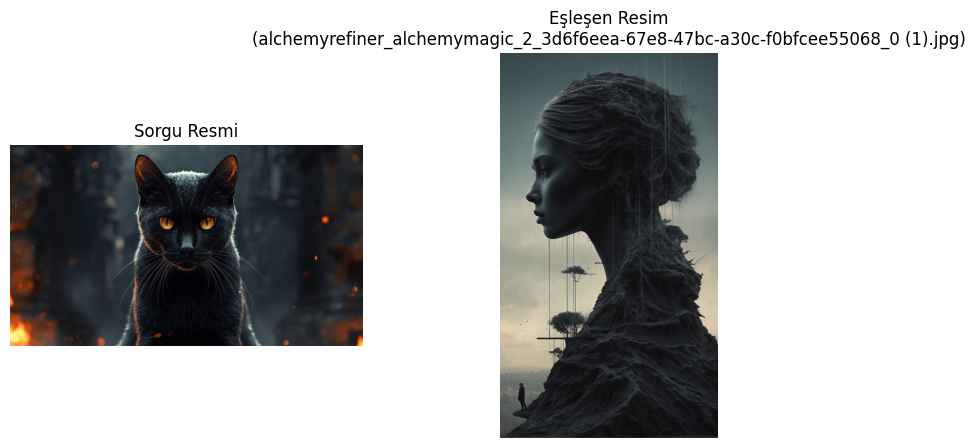

In [32]:
# 10. Sorgu resmi ile bulunan en benzer resmi yan yana gösterme
fig, eksenler = plt.subplots(1, 2, figsize=(10, 5))

eksenler[0].imshow(Image.open(test_yolu))
eksenler[0].set_title("Sorgu Resmi")
eksenler[0].axis("off")

eksenler[1].imshow(Image.open(resim_yollari[en_yakin_indeks]))
eksenler[1].set_title(f"Eşleşen Resim\n({resim_yollari[en_yakin_indeks]})")
eksenler[1].axis("off")

plt.show()